In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# We'll set up PyTorch as our backend, which is standard for modern CV tasks
import torch
import torchvision

# Verify the dataset is mounted correctly
dataset_path = '/kaggle/input'
for dirname, _, filenames in os.walk(dataset_path):
    for filename in filenames[:5]: # Print the first 5 files to verify
        print(os.path.join(dirname, filename))

# Confirm hardware acceleration
print(f"GPU Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device: {torch.cuda.get_device_name(0)}")

/kaggle/input/datasets/vaishnaviasonawane/indian-sign-language-dataset/data/N/623.jpg
/kaggle/input/datasets/vaishnaviasonawane/indian-sign-language-dataset/data/N/764.jpg
/kaggle/input/datasets/vaishnaviasonawane/indian-sign-language-dataset/data/N/1075.jpg
/kaggle/input/datasets/vaishnaviasonawane/indian-sign-language-dataset/data/N/771.jpg
/kaggle/input/datasets/vaishnaviasonawane/indian-sign-language-dataset/data/N/208.jpg
/kaggle/input/datasets/vaishnaviasonawane/indian-sign-language-dataset/data/7/623.jpg
/kaggle/input/datasets/vaishnaviasonawane/indian-sign-language-dataset/data/7/764.jpg
/kaggle/input/datasets/vaishnaviasonawane/indian-sign-language-dataset/data/7/1075.jpg
/kaggle/input/datasets/vaishnaviasonawane/indian-sign-language-dataset/data/7/771.jpg
/kaggle/input/datasets/vaishnaviasonawane/indian-sign-language-dataset/data/7/208.jpg
/kaggle/input/datasets/vaishnaviasonawane/indian-sign-language-dataset/data/R/623.jpg
/kaggle/input/datasets/vaishnaviasonawane/indian-sig

In [3]:
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, random_split

# 1. Define transformations
# We resize to 128x128 for efficient training and convert to PyTorch tensors.
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]) 
])

# 2. Point PyTorch to the exact data directory from your previous output
data_dir = '/kaggle/input/datasets/vaishnaviasonawane/indian-sign-language-dataset/data'

# ImageFolder automatically reads the subfolders as class labels
full_dataset = datasets.ImageFolder(root=data_dir, transform=transform)

# 3. Split the dataset (80% for training, 20% for validation)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

# Set a manual seed so our random split is reproducible if you restart the notebook
generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size], generator=generator)

# 4. Create DataLoaders to feed data to the GPU in manageable batches
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# 5. Print out the dataset statistics
classes = full_dataset.classes
print(f"Total number of classes: {len(classes)}")
print(f"Training images: {len(train_dataset)}")
print(f"Validation images: {len(val_dataset)}")
print(f"Classes found: {classes}")

Total number of classes: 35
Training images: 33600
Validation images: 8400
Classes found: ['1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


In [4]:
import torch.nn as nn
import torch.nn.functional as F

class ISLClassifier(nn.Module):
    def __init__(self, num_classes):
        super(ISLClassifier, self).__init__()
        
        # Block 1: 3 channels (RGB) in, 32 feature maps out
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        # Block 2: 32 in, 64 out
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        # Block 3: 64 in, 128 out
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        
        # Pooling layer to reduce spatial dimensions by half each time
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Dropout to prevent overfitting
        self.dropout = nn.Dropout(0.3)
        
        # Fully connected layers
        # Since our images are 128x128, passing through three 2x2 max pools cuts the size:
        # 128 -> 64 -> 32 -> 16. So the final spatial size is 16x16.
        self.fc1 = nn.Linear(128 * 16 * 16, 512)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        # Pass through convolutions, apply ReLU activation, then Max Pool
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        
        # Flatten the tensor for the dense layers
        x = torch.flatten(x, 1) 
        
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x) # No activation here, we'll use CrossEntropyLoss later
        return x

# Instantiate the model and send it to our Tesla T4 GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ISLClassifier(num_classes=35).to(device)

print(f"Model successfully built and moved to: {device}")
print(model)

Model successfully built and moved to: cuda
ISLClassifier(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=32768, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=35, bias=True)
)


In [5]:
import torch.optim as optim
import time

# 1. Define Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Number of times we loop over the entire dataset
epochs = 5 

print("Starting training... This will take a few minutes on the T4 GPU.")

for epoch in range(epochs):
    start_time = time.time()
    
    # --- TRAINING PHASE ---
    model.train() # Set model to training mode
    train_loss = 0.0
    train_correct = 0
    total_train = 0
    
    for images, labels in train_loader:
        # Move data to the GPU
        images, labels = images.to(device), labels.to(device)
        
        # Zero the gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass (calculate gradients)
        loss.backward()
        
        # Update weights
        optimizer.step()
        
        # Track metrics
        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        train_correct += (predicted == labels).sum().item()
        
    avg_train_loss = train_loss / len(train_loader)
    train_acc = 100 * train_correct / total_train
    
    # --- VALIDATION PHASE ---
    model.eval() # Set model to evaluation mode (disables dropout)
    val_loss = 0.0
    val_correct = 0
    total_val = 0
    
    # Disable gradient calculation for validation to save memory and compute
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            val_correct += (predicted == labels).sum().item()
            
    avg_val_loss = val_loss / len(val_loader)
    val_acc = 100 * val_correct / total_val
    
    end_time = time.time()
    epoch_mins = (end_time - start_time) / 60
    
    # Print the results for this epoch
    print(f"Epoch [{epoch+1}/{epochs}] | Time: {epoch_mins:.2f} mins")
    print(f"Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.2f}%\n")

print("Training Complete!")

Starting training... This will take a few minutes on the T4 GPU.
Epoch [1/5] | Time: 7.47 mins
Train Loss: 0.0794, Train Acc: 98.04%
Val Loss: 0.0001, Val Acc: 100.00%

Epoch [2/5] | Time: 2.29 mins
Train Loss: 0.0063, Train Acc: 99.84%
Val Loss: 0.0001, Val Acc: 100.00%

Epoch [3/5] | Time: 2.07 mins
Train Loss: 0.0010, Train Acc: 99.99%
Val Loss: 0.0000, Val Acc: 100.00%

Epoch [4/5] | Time: 1.99 mins
Train Loss: 0.0000, Train Acc: 100.00%
Val Loss: 0.0000, Val Acc: 100.00%

Epoch [5/5] | Time: 1.99 mins
Train Loss: 0.0038, Train Acc: 99.93%
Val Loss: 0.0000, Val Acc: 100.00%

Training Complete!


Model saved successfully to /kaggle/working/isl_cnn_model.pth


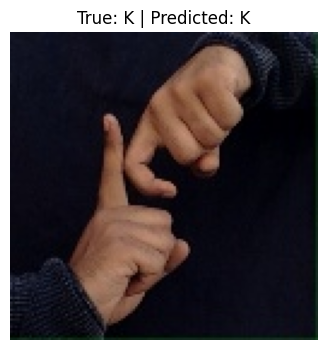

In [32]:
import random

# 1. Save the model weights to Kaggle's working directory
model_save_path = '/kaggle/working/isl_cnn_model.pth'
torch.save(model.state_dict(), model_save_path)
print(f"Model saved successfully to {model_save_path}")

# 2. Make a prediction on a random validation image
model.eval() # Ensure dropout is disabled for inference

# Get a single batch of images from the validation loader
dataiter = iter(val_loader)
images, labels = next(dataiter)

# Pick a random image index from this batch
idx = random.randint(0, batch_size - 1)

# PyTorch models expect a "batch" dimension, even for one image
# .unsqueeze(0) changes shape from (3, 128, 128) to (1, 3, 128, 128)
single_image = images[idx].unsqueeze(0).to(device) 
true_label_idx = labels[idx].item()

# Forward pass to get the prediction
with torch.no_grad():
    output = model(single_image)
    _, predicted_tensor = torch.max(output, 1)
    predicted_label_idx = predicted_tensor.item()

# 3. Visualize the result
# Convert the PyTorch tensor back to a format matplotlib can display
# We must reverse the normalization (mean=0.5, std=0.5) we applied in Step 2
img_display = images[idx].numpy().transpose((1, 2, 0))
img_display = img_display * np.array([0.5, 0.5, 0.5]) + np.array([0.5, 0.5, 0.5])
img_display = np.clip(img_display, 0, 1)

plt.figure(figsize=(4, 4))
plt.imshow(img_display)
plt.title(f"True: {classes[true_label_idx]} | Predicted: {classes[predicted_label_idx]}")
plt.axis('off')
plt.show()